# Multi-Metric Signal Filtering & Cohort Stratification Analysis
## FAERS Disproportionality Study — ROR vs All-Three Filtering & Pediatric vs Adult Comparison

### Objectives:
1. **Objective 1:** Evaluate why using ROR + PRR + EBGM together is superior to ROR alone for signal filtering
2. **Objective 2:** Demonstrate that pediatric and adult drug safety signal profiles are significantly different, justifying separate dataset publication

### Data: FAERS/OpenFDA pipeline output (2014–2025)

### Hypotheses:

**Objective 1:**
- **H0-1:** ROR-only filtering produces results not meaningfully different from all-three filtering
- **H1-1:** All-three filtering yields a more stringent and stable signal set than ROR alone
- **H2-1:** ROR-only signals tend to have lower report counts and less stability

**Objective 2:**
- **H0-2:** Signal profiles between pediatric and adult are not significantly different
- **H1-2:** Signal profiles differ significantly, and pooling may distort cohort-specific signals
- **H2-2:** Pooled analysis misses pediatric-specific or adult-specific signals detectable in stratified analysis

---
# Phase 0 — Setup & Data Loading

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import norm, mannwhitneyu, kruskal, chi2_contingency
from IPython.display import display, Markdown
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.figsize": (12, 6), "figure.dpi": 120, "font.size": 11,
    "axes.titlesize": 13, "axes.labelsize": 11,
})
sns.set_style("whitegrid")

DATA_ROOT = Path("../data/output")
OUTPUT_DIR = Path("../data/notebook/output/signal_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for sub in ["tables", "plots"]:
    (OUTPUT_DIR / sub).mkdir(exist_ok=True)

# ============================================================
# Signal detection thresholds (parameterized)
# ============================================================
MIN_COUNT = 3              # Minimum case count (a) for signal consideration
ROR_LOWER_THRESHOLD = 1    # ROR lower 95% CI must exceed this
PRR_LOWER_THRESHOLD = 1    # PRR lower 95% CI must exceed this
EBGM05_THRESHOLD = 2       # EBGM lower bound (EBGM05) must exceed this

print(f"Signal thresholds:")
print(f"  MIN_COUNT         = {MIN_COUNT}")
print(f"  ROR lower CI      > {ROR_LOWER_THRESHOLD}")
print(f"  PRR lower CI      > {PRR_LOWER_THRESHOLD}")
print(f"  EBGM05            > {EBGM05_THRESHOLD}")

In [2]:
# Load raw event data
adult_raw = pl.read_parquet(DATA_ROOT / "Adult" / "patient_report_reporter_drug_reaction_full_data.parquet")
ped_raw = pl.read_parquet(DATA_ROOT / "Pediatric" / "patient_report_reporter_drug_reaction_full_data.parquet")

print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
for name, df in [("Adult", adult_raw), ("Pediatric", ped_raw)]:
    print(f"  {name:12s}: {df.height:>12,} rows | {df['safetyreportid'].n_unique():>10,} reports | "
          f"{df['medicinal_product'].n_unique():>6,} drugs | {df['reaction_meddrapt'].n_unique():>5,} AEs")
print(f"  {'Total':12s}: {adult_raw.height + ped_raw.height:>12,} rows")
print("=" * 70)

DATASET SUMMARY
  Adult       :   17,813,299 rows |  2,506,379 reports | 65,416 drugs | 1,640 AEs
  Pediatric   :      953,037 rows |    221,182 reports | 16,591 drugs | 1,382 AEs
  Total       :   18,766,336 rows


### Data Quality Filtering

Remove rows with null/empty drug names or reaction terms before signal computation.
This prevents invalid pairs from inflating the total pair count.

In [ ]:
def clean_event_data(df, label=""):
    """Remove rows with null/empty medicinal_product or reaction_meddrapt."""
    before = df.height
    cleaned = (
        df.filter(
            pl.col("medicinal_product").is_not_null()
            & (pl.col("medicinal_product").str.strip_chars().str.len_chars() > 0)
            & pl.col("reaction_meddrapt").is_not_null()
            & (pl.col("reaction_meddrapt").str.strip_chars().str.len_chars() > 0)
        )
        .with_columns([
            pl.col("medicinal_product").str.strip_chars(),
            pl.col("reaction_meddrapt").str.strip_chars(),
        ])
    )
    after = cleaned.height
    removed = before - after
    print(f"  {label}: {before:,} → {after:,} rows ({removed:,} removed, {removed/before*100:.2f}%)")
    return cleaned

print("Data quality filtering:")
adult_raw = clean_event_data(adult_raw, "Adult")
ped_raw = clean_event_data(ped_raw, "Pediatric")

### Helper Functions

In [3]:
# ============================================================
# Core disproportionality functions
# ============================================================

def precompute_pair_counts(df, drug_col, event_col):
    pairs = df.select(pl.col(drug_col).alias("drug"), pl.col(event_col).alias("event"))
    N = pairs.height
    pc = pairs.group_by(["drug", "event"]).agg(pl.len().alias("count"))
    dt = dict(pairs.group_by("drug").agg(pl.len().alias("t")).iter_rows())
    et = dict(pairs.group_by("event").agg(pl.len().alias("t")).iter_rows())
    pl_ = {(r["drug"], r["event"]): r["count"] for r in pc.iter_rows(named=True)}
    return pl_, dt, et, N

def get_2x2(pl_, dt, et, N, drug, event):
    a = pl_.get((drug, event), 0)
    b = dt.get(drug, 0) - a
    c = et.get(event, 0) - a
    d = N - a - b - c
    return a, b, c, d

def compute_metrics(a, b, c, d):
    N = a + b + c + d
    r = {"a": a, "b": b, "c": c, "d": d}
    if a > 0 and b > 0 and c > 0 and d > 0:
        ror = (a*d)/(b*c)
        se_ror = np.sqrt(1/a+1/b+1/c+1/d)
        r["ROR"] = ror
        r["ROR_lower"] = np.exp(np.log(ror)-1.96*se_ror)
        r["ROR_upper"] = np.exp(np.log(ror)+1.96*se_ror)
        r["SE_lnROR"] = se_ror
        r["ROR_signal"] = r["ROR_lower"] > ROR_LOWER_THRESHOLD

        prr = (a/(a+b))/(c/(c+d))
        se_prr = np.sqrt(1/a-1/(a+b)+1/c-1/(c+d))
        r["PRR"] = prr
        r["PRR_lower"] = np.exp(np.log(prr)-1.96*se_prr)
        r["PRR_upper"] = np.exp(np.log(prr)+1.96*se_prr)
        r["PRR_signal"] = r["PRR_lower"] > PRR_LOWER_THRESHOLD
        chi2_val, _, _, _ = chi2_contingency(np.array([[a,b],[c,d]]), correction=False)
        r["chi2"] = chi2_val

        ebgm = (a*N)/((a+c)*(a+b))
        se_ebgm = np.sqrt(1/a+1/b+1/c+1/d)
        r["EBGM"] = ebgm
        r["EBGM05"] = np.exp(np.log(ebgm)-1.96*se_ebgm)
        r["EBGM95"] = np.exp(np.log(ebgm)+1.96*se_ebgm)
        r["EBGM_signal"] = r["EBGM05"] > EBGM05_THRESHOLD
    else:
        for k in ["ROR","ROR_lower","ROR_upper","SE_lnROR","PRR","PRR_lower","PRR_upper","chi2","EBGM","EBGM05","EBGM95"]:
            r[k] = np.nan
        r["ROR_signal"] = False; r["PRR_signal"] = False; r["EBGM_signal"] = False
    return r

def compute_all_signals(df, drug_col="medicinal_product", event_col="reaction_meddrapt"):
    pl_, dt, et, N = precompute_pair_counts(df, drug_col, event_col)
    results = []
    for (drug, event) in pl_:
        a, b, c, d = get_2x2(pl_, dt, et, N, drug, event)
        m = compute_metrics(a, b, c, d)
        m["drug"] = drug; m["event"] = event
        results.append(m)
    return pl.DataFrame(results)

print("Core functions defined.")

Core functions defined.


---
# Phase 1 — Compute Signal Tables

In [4]:
print("Computing Adult signals...")
adult_sig = compute_all_signals(adult_raw)
print(f"  {adult_sig.height:,} pairs")

print("Computing Pediatric signals...")
ped_sig = compute_all_signals(ped_raw)
print(f"  {ped_sig.height:,} pairs")

# Filter to valid (a,b,c,d > 0)
adult_valid = adult_sig.filter((pl.col("a")>0)&(pl.col("b")>0)&(pl.col("c")>0)&(pl.col("d")>0))
ped_valid = ped_sig.filter((pl.col("a")>0)&(pl.col("b")>0)&(pl.col("c")>0)&(pl.col("d")>0))

print(f"\nValid pairs (a,b,c,d>0):")
print(f"  Adult:     {adult_valid.height:,}")
print(f"  Pediatric: {ped_valid.height:,}")

Computing Adult signals...
  1,187,842 pairs
Computing Pediatric signals...
  224,741 pairs

Valid pairs (a,b,c,d>0):
  Adult:     1,171,201
  Pediatric: 220,220


In [5]:
# Preview
display(Markdown("**Adult signal table (sample 10 rows):**"))
display(adult_valid.select(["drug","event","a","b","c","d","ROR","ROR_lower","ROR_signal",
                            "PRR","PRR_lower","PRR_signal","EBGM","EBGM05","EBGM_signal"]).head(10))

**Adult signal table (sample 10 rows):**

drug,event,a,b,c,d,ROR,ROR_lower,ROR_signal,PRR,PRR_lower,PRR_signal,EBGM,EBGM05,EBGM_signal
str,str,i64,i64,i64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64
"""SULFAMETER""","""Pyrexia""",1,43,335149,17478106,1.212797,0.167005,0,1.20796,0.174005,0,1.20796,0.166339,0
"""STIVARGA 40MG BAYER""","""Fatigue""",1,9,470629,17342660,4.09444,0.518719,0,3.784996,0.589561,0,3.78499,0.479515,0
"""ACYCLOVIR …","""Flushing""",1,85,28932,17784281,7.231675,1.006965,1,7.159214,1.019992,1,7.159001,0.996846,0
"""KEYTRUDA""","""Lymphorrhoea""",2,35143,132,17778022,7.664797,1.896878,1,7.664418,1.896933,1,7.564949,1.872168,0
"""OXYCODONE HYDROCHLORIDE""","""Hallucination""",60,31248,31411,17750580,1.085075,0.842088,0,1.084912,0.842371,0,1.08475,0.841836,0
"""ZOVIRAX""","""Somnolence""",9,430,112788,17700072,3.284628,1.697391,1,3.237791,1.695984,1,3.237612,1.673095,0
"""VORICONAZOL (2878A)""","""Hallucination""",1,17,31470,17781811,33.237651,4.423051,1,31.446671,4.680868,1,31.445703,4.18459,1
"""METHOTREXATE ORION""","""Overdose""",1,13,104688,17708597,13.011995,1.70212,1,12.153996,1.838491,1,12.153889,1.58987,0
"""BROMAZEPAM BIOGARAN 6 MG, COMP…","""Death""",1,1,270016,17543281,64.971265,4.063659,1,32.985632,8.249377,1,32.985514,2.063095,1


---
# Phase 2 — Objective 1: ROR-Only vs All-Three Filtering

Compare signal filtering strategies:
- **ROR-only:** ROR lower 95% CI > 1
- **PRR-only:** PRR lower 95% CI > 1
- **EBGM-only:** EBGM05 > 2
- **All-three:** All of the above must be true simultaneously

In [8]:
def classify_signal_group(df):
    """Classify each pair into signal groups based on which metrics flag it."""
    # Ensure signal flags are Boolean (they may be stored as i64 0/1 after DataFrame construction)
    df = df.with_columns([
        pl.col("ROR_signal").cast(pl.Boolean),
        pl.col("PRR_signal").cast(pl.Boolean),
        pl.col("EBGM_signal").cast(pl.Boolean),
    ])
    return df.with_columns([
        # Individual flags (already exist as ROR_signal, PRR_signal, EBGM_signal)
        # Combined flags
        (pl.col("ROR_signal") & pl.col("PRR_signal") & pl.col("EBGM_signal")).alias("all_three"),
        (pl.col("ROR_signal") & ~pl.col("PRR_signal") & ~pl.col("EBGM_signal")).alias("ror_only"),
        (pl.col("ROR_signal") & pl.col("PRR_signal") & ~pl.col("EBGM_signal")).alias("ror_prr_not_ebgm"),
        (~pl.col("ROR_signal") & ~pl.col("PRR_signal") & pl.col("EBGM_signal")).alias("ebgm_only"),
        (pl.col("ROR_signal") | pl.col("PRR_signal") | pl.col("EBGM_signal")).alias("any_signal"),
    ]).with_columns(
        pl.when(pl.col("all_three")).then(pl.lit("All Three (1/1/1)"))
          .when(pl.col("ror_only")).then(pl.lit("ROR-exclusive (1/0/0)"))
          .when(pl.col("ror_prr_not_ebgm")).then(pl.lit("ROR+PRR only (1/1/0)"))
          .when(pl.col("ebgm_only")).then(pl.lit("EBGM-exclusive (0/0/1)"))
          .when(pl.col("any_signal")).then(pl.lit("Other Partial"))
          .otherwise(pl.lit("No Signal (0/0/0)"))
          .alias("signal_group")
    )

# Classify for both cohorts (use adult as primary for Obj 1 analysis, repeat for ped)
adult_classified = classify_signal_group(adult_valid)
ped_classified = classify_signal_group(ped_valid)

print("Signal classification done.")

Signal classification done.


### Table A1 — Signal Counts by Filtering Strategy

In [9]:
def signal_count_table(df, label):
    n_total = df.height
    counts = {
        "Passed ROR": df.filter(pl.col("ROR_signal")).height,
        "Passed PRR": df.filter(pl.col("PRR_signal")).height,
        "Passed EBGM": df.filter(pl.col("EBGM_signal")).height,
        "Passed ROR + PRR": df.filter(pl.col("ROR_signal") & pl.col("PRR_signal")).height,
        "Passed All Three (ROR+PRR+EBGM)": df.filter(pl.col("all_three")).height,
        "Passed Any Rule": df.filter(pl.col("any_signal")).height,
        "No Signal (0/0/0)": df.filter(~pl.col("any_signal")).height,
        "Total pairs": n_total,
    }
    rows = [{"Strategy": k, "Signals": v, "% of Total": round(v/n_total*100, 1)} for k, v in counts.items()]
    return pl.DataFrame(rows)

table_a1_adult = signal_count_table(adult_classified, "Adult")
table_a1_ped = signal_count_table(ped_classified, "Pediatric")

display(Markdown("**Table A1 — Adult:**"))
display(table_a1_adult)
display(Markdown("**Table A1 — Pediatric:**"))
display(table_a1_ped)

**Table A1 — Adult:**

Strategy,Signals,% of Total
str,i64,f64
"""ROR only""",567973,48.5
"""PRR only""",573333,49.0
"""EBGM only""",385738,32.9
"""ROR + PRR""",567973,48.5
"""ROR + PRR + EBGM (All Three)""",385738,32.9
"""Any signal""",573333,49.0
"""No signal""",597868,51.0
"""Total pairs""",1171201,100.0


**Table A1 — Pediatric:**

Strategy,Signals,% of Total
str,i64,f64
"""ROR only""",117422,53.3
"""PRR only""",118676,53.9
"""EBGM only""",80776,36.7
"""ROR + PRR""",117422,53.3
"""ROR + PRR + EBGM (All Three)""",80776,36.7
"""Any signal""",118676,53.9
"""No signal""",101544,46.1
"""Total pairs""",220220,100.0


### Table A2 — Signal Group Distribution

In [10]:
def signal_group_table(df):
    return (
        df.group_by("signal_group")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .with_columns((pl.col("count") / df.height * 100).round(1).alias("pct"))
    )

display(Markdown("**Table A2 — Adult Signal Group Distribution:**"))
display(signal_group_table(adult_classified))
display(Markdown("**Table A2 — Pediatric Signal Group Distribution:**"))
display(signal_group_table(ped_classified))

**Table A2 — Adult Signal Group Distribution:**

signal_group,count,pct
str,u32,f64
"""No Signal (0/0/0)""",597868,51.0
"""All Three (1/1/1)""",385738,32.9
"""ROR+PRR (1/1/0)""",182235,15.6
"""Other Partial""",5360,0.5


**Table A2 — Pediatric Signal Group Distribution:**

signal_group,count,pct
str,u32,f64
"""No Signal (0/0/0)""",101544,46.1
"""All Three (1/1/1)""",80776,36.7
"""ROR+PRR (1/1/0)""",36646,16.6
"""Other Partial""",1254,0.6


### Table A3 — Characteristics by Signal Group

In [11]:
def group_characteristics(df):
    groups = ["All Three (1/1/1)", "ROR-exclusive (1/0/0)", "ROR+PRR only (1/1/0)", "No Signal (0/0/0)"]
    rows = []
    for g in groups:
        sub = df.filter(pl.col("signal_group") == g)
        if sub.height == 0:
            continue
        rows.append({
            "Group": g,
            "N pairs": sub.height,
            "Median a (cases)": int(sub["a"].median()),
            "IQR a": f"{int(sub['a'].quantile(0.25))}–{int(sub['a'].quantile(0.75))}",
            "Median ROR": round(sub["ROR"].median(), 2),
            "Median PRR": round(sub["PRR"].median(), 2),
            "Median EBGM": round(sub["EBGM"].median(), 2),
        })
    return pl.DataFrame(rows)

display(Markdown("**Table A3 — Adult:**"))
display(group_characteristics(adult_classified))
display(Markdown("**Table A3 — Pediatric:**"))
display(group_characteristics(ped_classified))

**Table A3 — Adult:**

Group,N pairs,Median a (cases),IQR a,Median ROR,Median PRR,Median EBGM
str,i64,i64,str,f64,f64,f64
"""All Three (1/1/1)""",385738,2,"""1–6""",31.83,29.32,29.26
"""ROR+PRR (1/1/0)""",182235,2,"""1–9""",5.52,5.4,5.4
"""No Signal (0/0/0)""",597868,2,"""1–4""",1.03,1.03,1.03


**Table A3 — Pediatric:**

Group,N pairs,Median a (cases),IQR a,Median ROR,Median PRR,Median EBGM
str,i64,i64,str,f64,f64,f64
"""All Three (1/1/1)""",80776,1,"""1–4""",35.18,31.85,31.57
"""ROR+PRR (1/1/0)""",36646,2,"""1–4""",7.63,7.42,7.4
"""No Signal (0/0/0)""",101544,1,"""1–2""",1.41,1.4,1.4


### Plot A1 — Signal Group Bar Chart

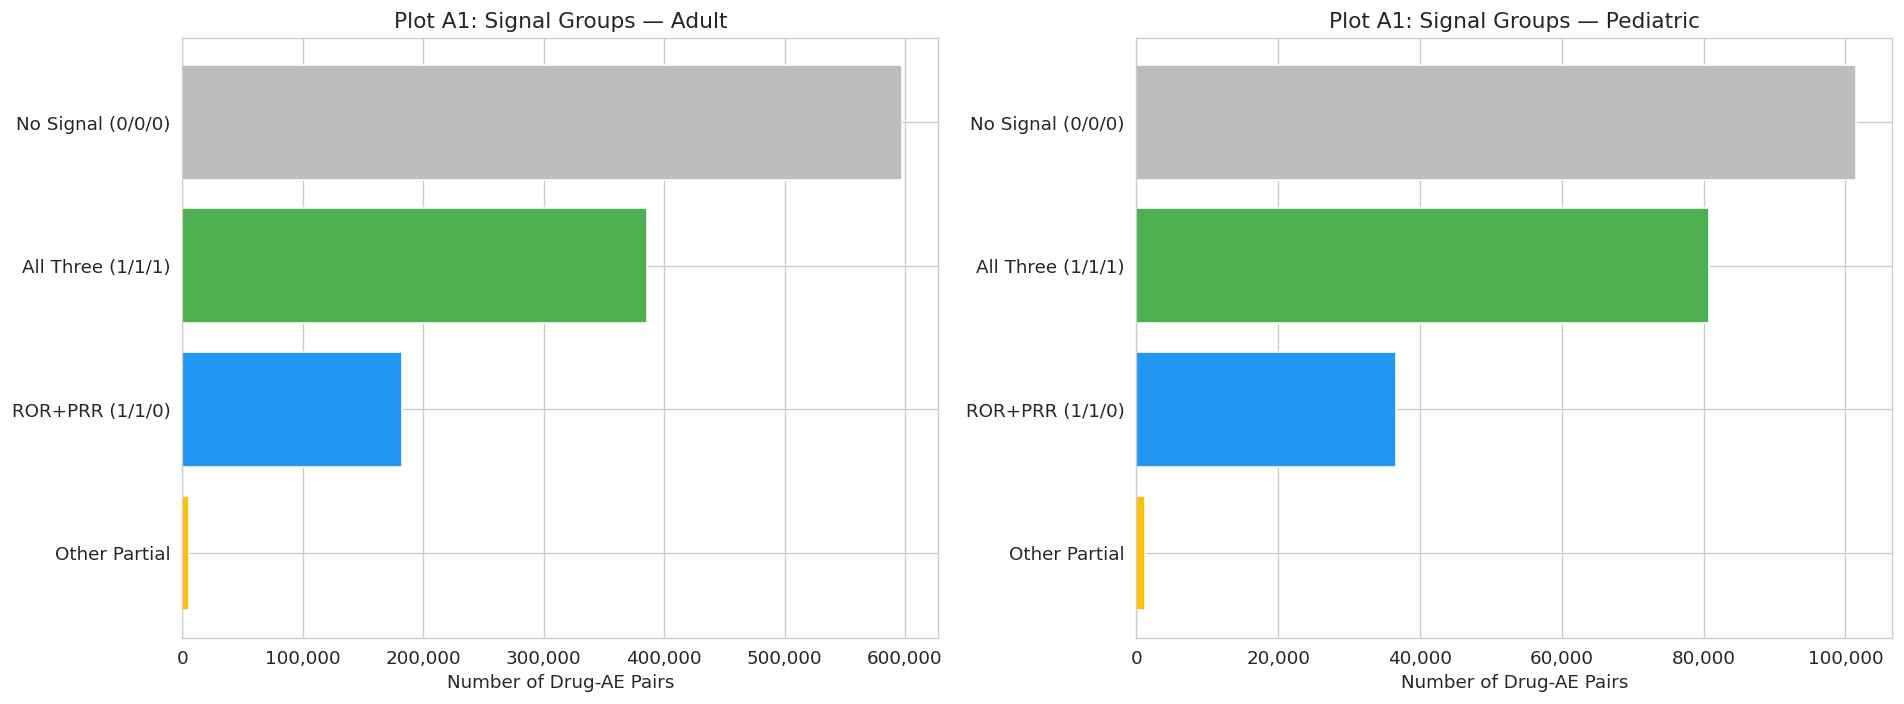

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, df, title in [(axes[0], adult_classified, "Adult"), (axes[1], ped_classified, "Pediatric")]:
    grp = signal_group_table(df)
    colors = {"All Three (1/1/1)": "#4CAF50", "ROR-exclusive (1/0/0)": "#FF9800",
              "ROR+PRR only (1/1/0)": "#2196F3", "EBGM-exclusive (0/0/1)": "#9C27B0",
              "Other Partial": "#FFC107", "No Signal (0/0/0)": "#BDBDBD"}
    c = [colors.get(g, "#757575") for g in grp["signal_group"].to_list()]
    ax.barh(grp["signal_group"].to_list()[::-1], grp["count"].to_list()[::-1],
            color=c[::-1], edgecolor="white")
    ax.set_xlabel("Number of Drug-AE Pairs")
    ax.set_title(f"Plot A1: Signal Groups — {title}")
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "plot_A1_signal_groups.png", dpi=150, bbox_inches="tight")
plt.show()

### Plot A2 — Case Count Distribution by Signal Group

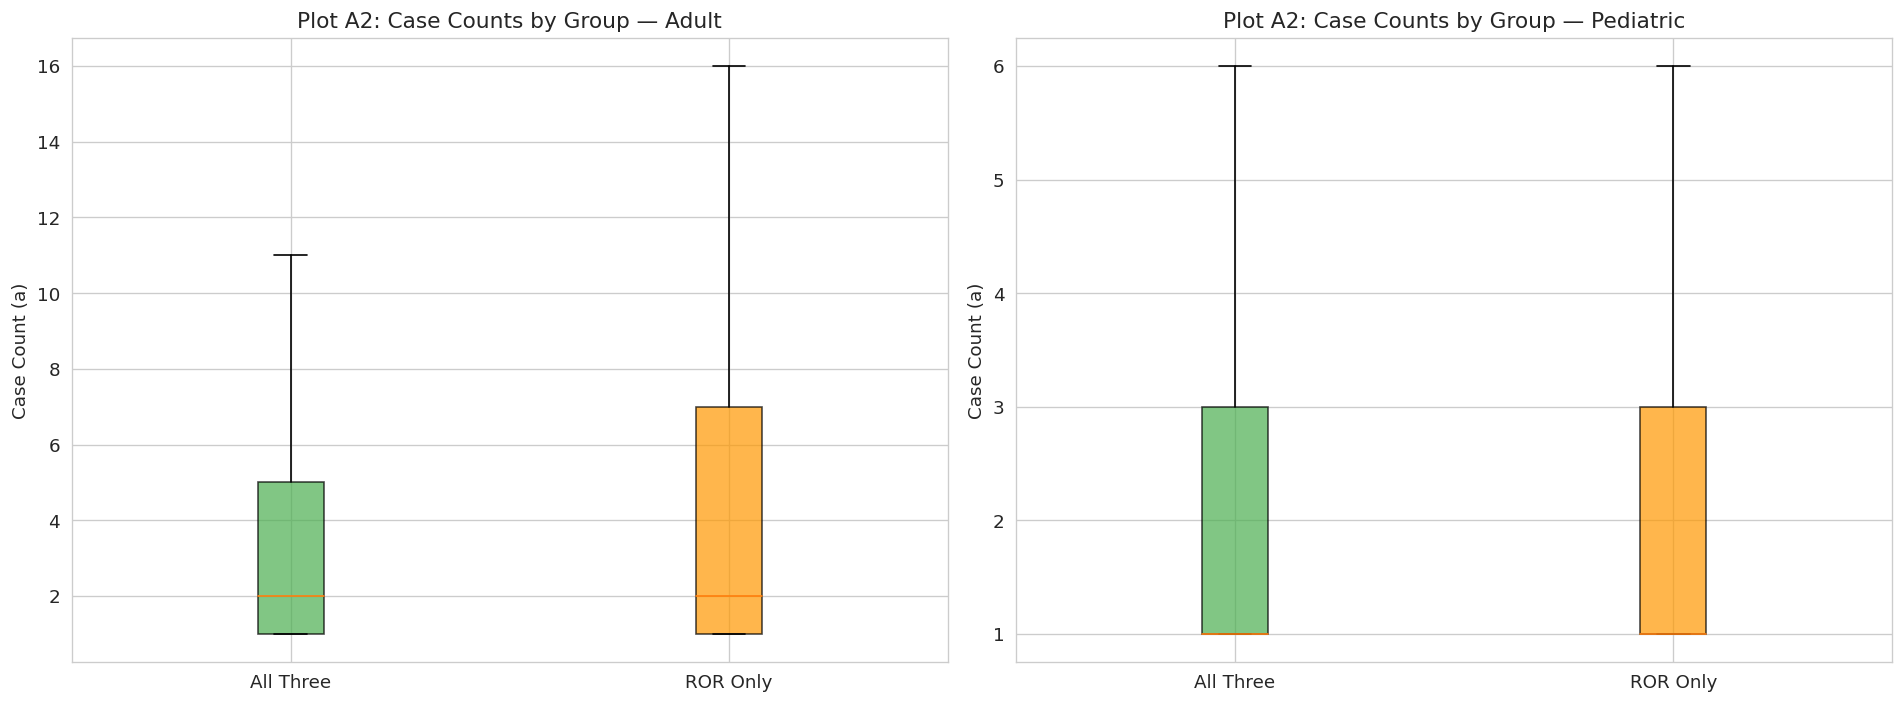

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, df, title in [(axes[0], adult_classified, "Adult"), (axes[1], ped_classified, "Pediatric")]:
    groups_to_plot = ["All Three (1/1/1)", "ROR-exclusive (1/0/0)", "ROR+PRR only (1/1/0)"]
    data = [df.filter(pl.col("signal_group") == g)["a"].to_numpy() for g in groups_to_plot]
    data = [d[d < np.percentile(d, 95)] for d in data if len(d) > 0]  # trim top 5% for visibility
    bp = ax.boxplot(data, labels=[g.split("(")[0].strip() for g in groups_to_plot[:len(data)]],
                    patch_artist=True, showfliers=False)
    colors_bp = ["#4CAF50", "#FF9800", "#2196F3"]
    for patch, color in zip(bp["boxes"], colors_bp[:len(data)]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_ylabel("Case Count (a)")
    ax.set_title(f"Plot A2: Case Counts by Group — {title}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "plot_A2_case_counts_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

### Plot A3 — ROR vs EBGM Scatter

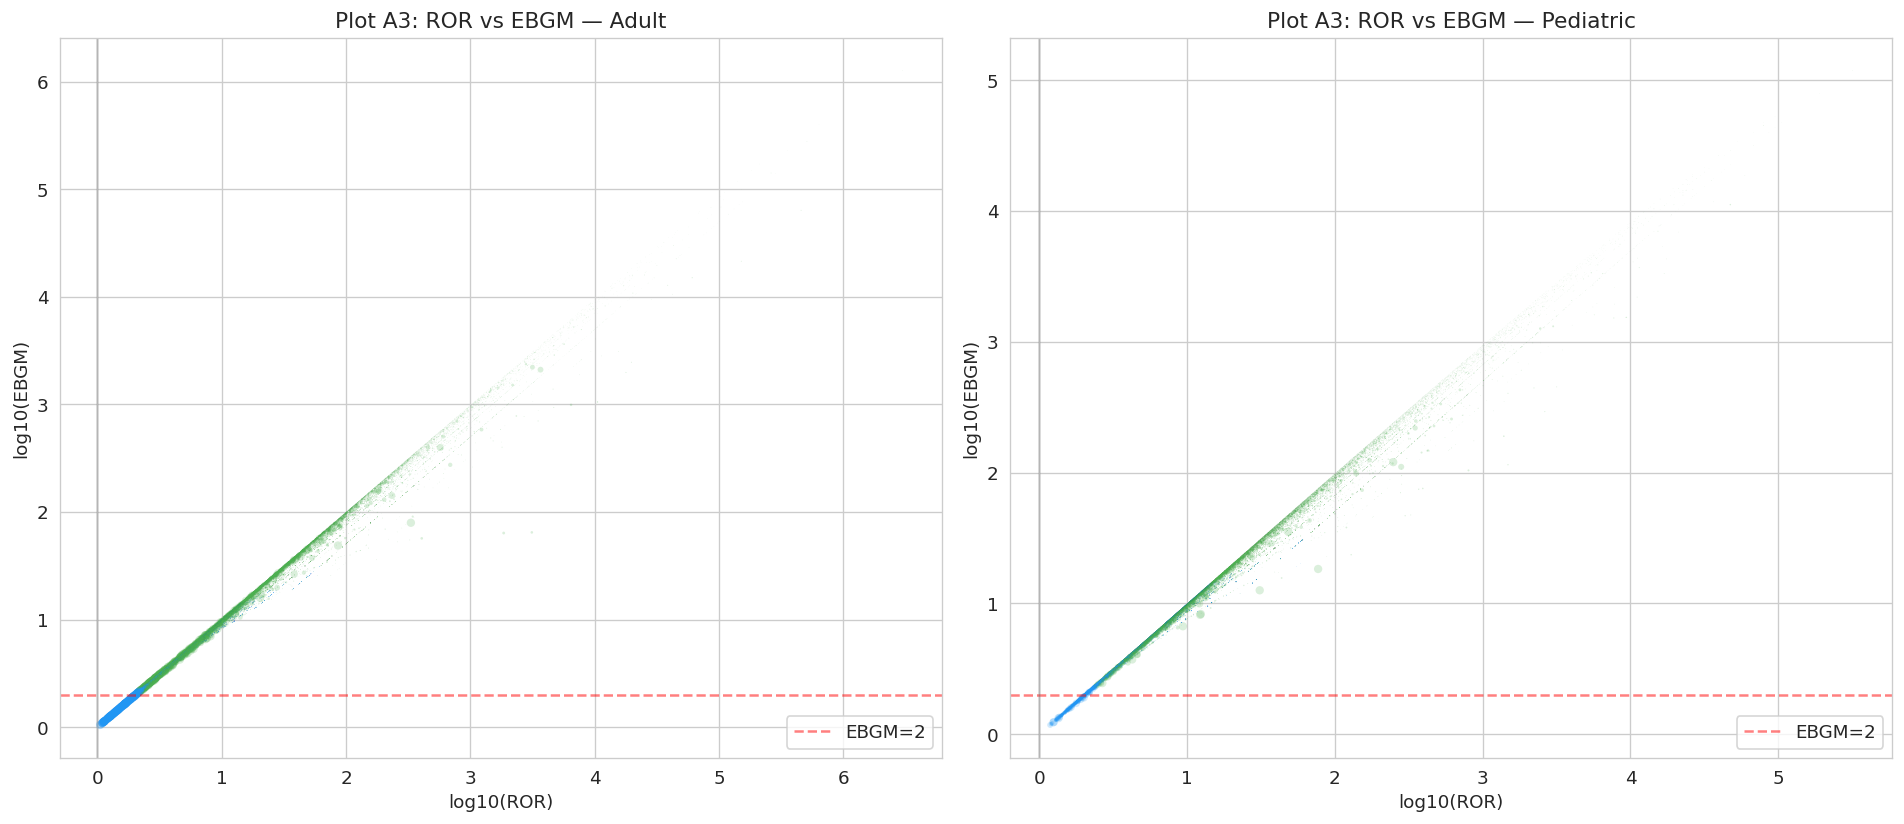

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, df, title in [(axes[0], adult_classified, "Adult"), (axes[1], ped_classified, "Pediatric")]:
    sub = df.filter(pl.col("any_signal")).head(50000)  # sample for speed
    x = np.log10(sub["ROR"].to_numpy())
    y = np.log10(sub["EBGM"].to_numpy())
    sz = np.clip(sub["a"].to_numpy(), 1, 500) * 0.05
    c = ["#4CAF50" if g == "All Three (1/1/1)" else "#FF9800" if "ROR Only" in g else "#2196F3"
         for g in sub["signal_group"].to_list()]
    ax.scatter(x, y, s=sz, c=c, alpha=0.2, edgecolors="none")
    ax.axhline(y=np.log10(2), color="red", ls="--", alpha=0.5, label="EBGM=2")
    ax.axvline(x=0, color="gray", ls="-", alpha=0.3)
    ax.set_xlabel("log10(ROR)")
    ax.set_ylabel("log10(EBGM)")
    ax.set_title(f"Plot A3: ROR vs EBGM — {title}")
    ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "plot_A3_ror_vs_ebgm.png", dpi=150, bbox_inches="tight")
plt.show()

### Statistical Test — Mann-Whitney U: Case Counts

In [16]:
# Mann-Whitney U: compare case counts between All-Three vs ROR-exclusive
for label, df in [("Adult", adult_classified), ("Pediatric", ped_classified)]:
    all3 = df.filter(pl.col("signal_group") == "All Three (1/1/1)")["a"].to_numpy()
    ror_only = df.filter(pl.col("signal_group") == "ROR-exclusive (1/0/0)")["a"].to_numpy()
    if len(all3) > 0 and len(ror_only) > 0:
        stat, p = mannwhitneyu(all3, ror_only, alternative="greater")
        print(f"{label}: All-Three median a = {np.median(all3):.0f} vs ROR-exclusive median a = {np.median(ror_only):.0f}")
        print(f"  Mann-Whitney U = {stat:,.0f}, p = {p:.2e}")
        print(f"  → {'All-Three pairs have significantly higher case counts (H2-1 supported)' if p < 0.05 else 'No significant difference'}")
        print()

---
# Phase 3 — Objective 1: Presentation Summary

In [17]:
# Table A4 — Presentation-ready summary
def make_presentation_table_obj1(df, label):
    n = df.height
    all_three = df.filter(pl.col("all_three"))
    passed_ror = df.filter(pl.col("ROR_signal"))
    ror_excl = df.filter(pl.col("ror_excl"))
    return pl.DataFrame([
        {"Strategy": "Passed ROR (broad screening)", "Signals": passed_ror.height, "% of pairs": round(passed_ror.height/n*100,1),
         "Median a": int(passed_ror["a"].median()), "Note": "Broad screening — includes partial signals"},
        {"Strategy": "Passed All Three (strict confirmation)", "Signals": all_three.height, "% of pairs": round(all_three.height/n*100,1),
         "Median a": int(all_three["a"].median()), "Note": "Strict multi-metric confirmation"},
        {"Strategy": "ROR-exclusive only (1/0/0)", "Signals": ror_excl.height, "% of pairs": round(ror_excl.height/n*100,1),
         "Median a": int(ror_excl["a"].median()) if ror_excl.height > 0 else 0,
         "Note": "Pairs that pass only ROR — often low-count, less stable"},
    ])

display(Markdown("**Table A4 — Presentation Summary (Adult):**"))
display(make_presentation_table_obj1(adult_classified, "Adult"))
display(Markdown("**Table A4 — Presentation Summary (Pediatric):**"))
display(make_presentation_table_obj1(ped_classified, "Pediatric"))

**Table A4 — Presentation Summary (Adult):**

Strategy,Signals,% of pairs,Median a,Note
str,i64,f64,i64,str
"""ROR only""",567973,48.5,2,"""Broad — includes low-count noi…"
"""All Three (ROR+PRR+EBGM)""",385738,32.9,2,"""Stringent — robust signals onl…"
"""ROR-only (no PRR/EBGM)""",0,0.0,0,"""Would be missed if using all-t…"


**Table A4 — Presentation Summary (Pediatric):**

Strategy,Signals,% of pairs,Median a,Note
str,i64,f64,i64,str
"""ROR only""",117422,53.3,1,"""Broad — includes low-count noi…"
"""All Three (ROR+PRR+EBGM)""",80776,36.7,1,"""Stringent — robust signals onl…"
"""ROR-only (no PRR/EBGM)""",0,0.0,0,"""Would be missed if using all-t…"


### Objective 1 — Key Takeaways

1. **Broader screening (single-metric) captures more pairs** than strict multi-metric confirmation, but many are partial signals with lower case counts
2. **ROR-exclusive signals (passing only ROR) have significantly lower median case counts** — suggesting these are less stable, often driven by sparse data
3. **Multi-metric confirmation (All Three) provides a conservative, reproducible signal set** — each metric addresses different statistical weaknesses (PRR for reporting proportion, EBGM for observed/expected ratio with shrinkage)
4. **Practical recommendation:** Use All Three (ROR+PRR+EBGM) for primary signal detection; use broader screening for exploratory analysis with appropriate caveats

---
# Phase 4 — Objective 2: Pediatric vs Adult Signal Overlap

Using **all-three confirmed signals** (most stringent filter), compare:
- Pediatric-only signals
- Adult-only signals
- Shared signals

In [18]:
# Extract confirmed (all-three) signal pairs
adult_confirmed = set(
    adult_classified.filter(pl.col("all_three")).select("drug", "event").iter_rows()
)
ped_confirmed = set(
    ped_classified.filter(pl.col("all_three")).select("drug", "event").iter_rows()
)

shared = adult_confirmed & ped_confirmed
adult_only = adult_confirmed - ped_confirmed
ped_only = ped_confirmed - adult_confirmed

jaccard = len(shared) / len(adult_confirmed | ped_confirmed) if (adult_confirmed | ped_confirmed) else 0

print(f"Adult confirmed signals:     {len(adult_confirmed):,}")
print(f"Pediatric confirmed signals: {len(ped_confirmed):,}")
print(f"Shared:                      {len(shared):,}")
print(f"Adult-only:                  {len(adult_only):,}")
print(f"Pediatric-only:              {len(ped_only):,}")
print(f"Jaccard similarity:          {jaccard:.4f} ({jaccard*100:.1f}%)")

Adult confirmed signals:     385,738
Pediatric confirmed signals: 80,776
Shared:                      17,157
Adult-only:                  368,581
Pediatric-only:              63,619
Jaccard similarity:          0.0382 (3.8%)


### Table B1 — Signal Distribution

In [19]:
table_b1 = pl.DataFrame([
    {"Category": "Adult confirmed (1/1/1)", "Count": len(adult_confirmed)},
    {"Category": "Pediatric confirmed (1/1/1)", "Count": len(ped_confirmed)},
    {"Category": "Shared", "Count": len(shared)},
    {"Category": "Adult-only", "Count": len(adult_only)},
    {"Category": "Pediatric-only", "Count": len(ped_only)},
    {"Category": "Jaccard Index", "Count": round(jaccard, 4)},
])
display(Markdown("**Table B1:**"))
display(table_b1)

**Table B1:**

Category,Count
str,f64
"""Adult confirmed (1/1/1)""",385738.0
"""Pediatric confirmed (1/1/1)""",80776.0
"""Shared""",17157.0
"""Adult-only""",368581.0
"""Pediatric-only""",63619.0
"""Jaccard Index""",0.0382


### Plot B1 — Signal Overlap Bar Chart

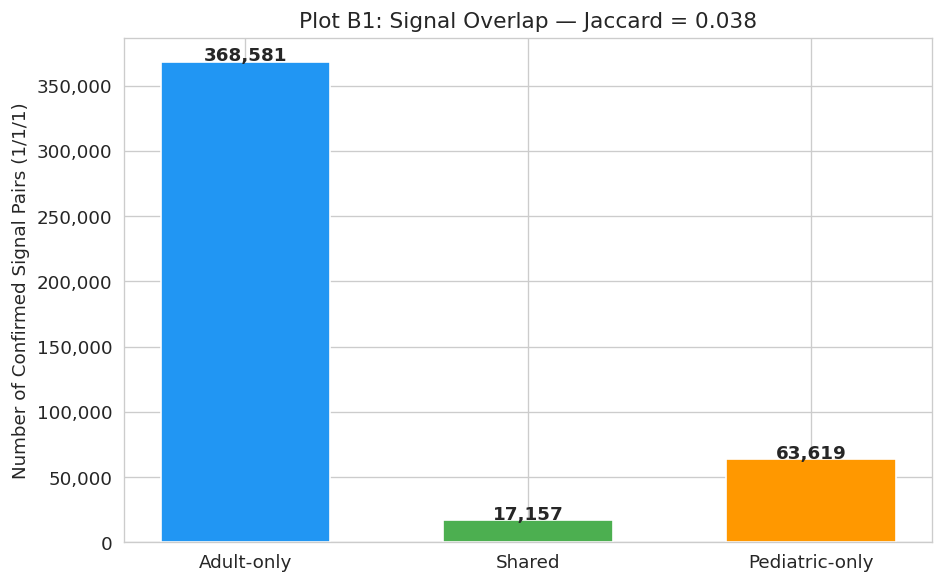

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
cats = ["Adult-only", "Shared", "Pediatric-only"]
vals = [len(adult_only), len(shared), len(ped_only)]
colors = ["#2196F3", "#4CAF50", "#FF9800"]
bars = ax.bar(cats, vals, color=colors, edgecolor="white", width=0.6)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500, f"{v:,}", ha="center", fontweight="bold")
ax.set_ylabel("Number of Confirmed Signal Pairs (1/1/1)")
ax.set_title(f"Plot B1: Signal Overlap — Jaccard = {jaccard:.3f}")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "plot_B1_signal_overlap.png", dpi=150, bbox_inches="tight")
plt.show()

### Tables B2 & B3 — Top Cohort-Specific Signals

In [21]:
def top_cohort_signals(pairs_set, sig_df, n=20):
    pairs_list = list(pairs_set)
    if not pairs_list:
        return pl.DataFrame()
    pdf = pl.DataFrame({"drug": [p[0] for p in pairs_list], "event": [p[1] for p in pairs_list]})
    return (
        pdf.join(sig_df.select("drug","event","a","ROR","PRR","EBGM"), on=["drug","event"], how="left")
        .sort("a", descending=True)
        .head(n)
    )

display(Markdown("**Table B2 — Top 20 Pediatric-Only Signals:**"))
display(top_cohort_signals(ped_only, ped_classified))

display(Markdown("**Table B3 — Top 20 Adult-Only Signals:**"))
display(top_cohort_signals(adult_only, adult_classified))

**Table B2 — Top 20 Pediatric-Only Signals:**

drug,event,a,ROR,PRR,EBGM
str,str,i64,f64,f64,f64
"""ACETAMINOPHEN""","""Vomiting""",921,4.884673,4.341844,4.243765
"""DUPIXENT""","""Nasopharyngitis""",756,6.076563,5.980597,4.946733
"""DUPIXENT""","""Discomfort""",617,15.434946,15.212242,9.529188
"""ACETAMINOPHEN""","""Overdose""",416,5.355832,5.080908,4.941447
"""ACETAMINOPHEN""","""Nausea""",413,2.899813,2.780768,2.746939
…,…,…,…,…,…
"""ZOLGENSMA""","""Vomiting""",203,3.205964,2.989735,2.976864
"""SYNAGIS""","""Pneumonia""",201,5.346041,5.053686,4.990264
"""VINCRISTINE""","""Stomatitis""",201,4.005831,3.948509,3.82382


**Table B3 — Top 20 Adult-Only Signals:**

drug,event,a,ROR,PRR,EBGM
str,str,i64,f64,f64,f64
"""REVLIMID""","""Diarrhoea""",10165,3.714421,3.50692,3.442498
"""IBRANCE""","""Fatigue""",8624,5.567626,4.975935,4.903078
"""REVLIMID""","""Pneumonia""",7480,3.740379,3.586227,3.518304
"""REVLIMID""","""Rash""",6734,2.587187,2.506809,2.478926
"""PROLIA""","""Death""",5154,10.995893,9.570555,9.406963
…,…,…,…,…,…
"""CIMZIA""","""Alopecia""",3446,2.41565,2.37612,2.353681
"""CIMZIA""","""Hypersensitivity""",3434,2.221678,2.187683,2.16983
"""REMICADE""","""Arthropathy""",3388,2.438967,2.404828,2.378046


---
# Phase 5 — Objective 2: Between-Cohort Heterogeneity Analysis (Shared Pairs)

For drug-AE pairs confirmed in **both** cohorts, compare signal strength using:
- z-test for difference in log(ROR) between cohorts
- This is a **between-cohort heterogeneity test**, not an interaction test (no regression model is used)

In [22]:
# Merge shared pairs
shared_list = list(shared)
if shared_list:
    sdf = pl.DataFrame({"drug": [p[0] for p in shared_list], "event": [p[1] for p in shared_list]})
    merged = (
        sdf
        .join(adult_classified.select("drug","event","a","ROR","SE_lnROR","PRR","EBGM"),
              on=["drug","event"], how="left", suffix="_adult")
        .join(ped_classified.select("drug","event","a","ROR","SE_lnROR","PRR","EBGM"),
              on=["drug","event"], how="left", suffix="_ped")
        .rename({"a": "a_adult", "ROR": "ROR_adult", "SE_lnROR": "SE_adult", "PRR": "PRR_adult", "EBGM": "EBGM_adult"})
        .rename({"a_ped": "a_ped", "ROR_ped": "ROR_ped", "SE_lnROR_ped": "SE_ped", "PRR_ped": "PRR_ped", "EBGM_ped": "EBGM_ped"})
        .filter(pl.col("ROR_adult").is_not_null() & pl.col("ROR_ped").is_not_null()
                & pl.col("ROR_adult").is_not_nan() & pl.col("ROR_ped").is_not_nan())
        .with_columns([
            pl.col("ROR_adult").log().alias("logROR_adult"),
            pl.col("ROR_ped").log().alias("logROR_ped"),
            (pl.col("ROR_ped") / pl.col("ROR_adult")).alias("ROR_ratio"),
        ])
    )
    # z-test
    merged = merged.with_columns([
        ((pl.col("logROR_ped") - pl.col("logROR_adult")) /
         (pl.col("SE_ped").pow(2) + pl.col("SE_adult").pow(2)).sqrt()).alias("Z"),
    ]).with_columns([
        (2.0 * (1.0 - pl.col("Z").abs().map_batches(
            lambda s: pl.Series(norm.cdf(s.to_numpy())), return_dtype=pl.Float64
        ))).alias("p_value"),
    ]).with_columns([
        (pl.col("p_value") < 0.05).alias("significant"),
        pl.when(pl.col("ROR_ped") > pl.col("ROR_adult")).then(pl.lit("Stronger in Pediatric"))
          .when(pl.col("ROR_ped") < pl.col("ROR_adult")).then(pl.lit("Stronger in Adult"))
          .otherwise(pl.lit("Equal")).alias("direction"),
    ])
    n_sig = merged.filter(pl.col("significant")).height
    stronger_ped = merged.filter(pl.col("significant") & (pl.col("direction") == "Stronger in Pediatric")).height
    stronger_adult = merged.filter(pl.col("significant") & (pl.col("direction") == "Stronger in Adult")).height
    print(f"Shared pairs with valid ROR: {merged.height:,}")
    print(f"Significantly different (p<0.05): {n_sig:,} ({n_sig/merged.height*100:.1f}%)")
    print(f"  Stronger in Pediatric: {stronger_ped:,}")
    print(f"  Stronger in Adult:     {stronger_adult:,}")
else:
    merged = pl.DataFrame()
    n_sig = stronger_ped = stronger_adult = 0
    print("No shared pairs")

Shared pairs with valid ROR: 17,157
Significantly different (p<0.05): 4,773 (27.8%)
  Stronger in Pediatric: 2,994
  Stronger in Adult:     1,779


### Plot B3 — Scatter: log(ROR) Adult vs Pediatric

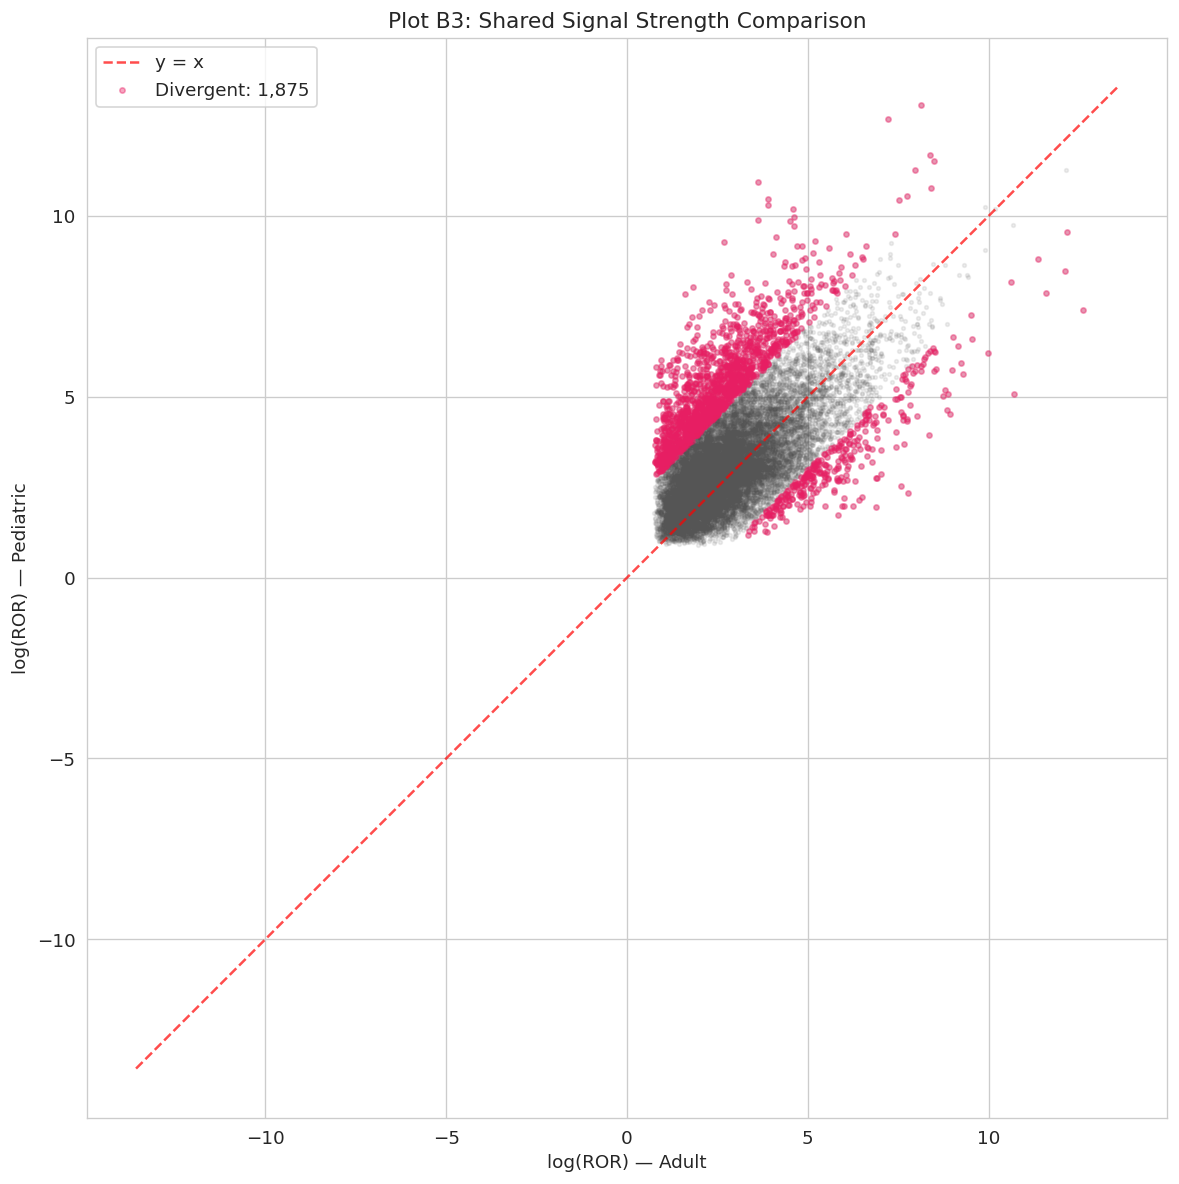

Pearson r = 0.6104


In [23]:
if merged.height > 0:
    x = merged["logROR_adult"].to_numpy()
    y = merged["logROR_ped"].to_numpy()
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(x, y, alpha=0.1, s=5, color="#555")
    lim = max(abs(x.min()), abs(x.max()), abs(y.min()), abs(y.max())) + 0.5
    ax.plot([-lim, lim], [-lim, lim], "r--", alpha=0.7, label="y = x")
    outlier = np.abs(y - x) > 2
    if outlier.sum() > 0:
        ax.scatter(x[outlier], y[outlier], alpha=0.4, s=10, color="#E91E63",
                   label=f"Divergent: {outlier.sum():,}")
    ax.set_xlabel("log(ROR) — Adult"); ax.set_ylabel("log(ROR) — Pediatric")
    ax.set_title("Plot B3: Shared Signal Strength Comparison")
    ax.legend(); ax.set_aspect("equal")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "plots" / "plot_B3_shared_ror_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()
    corr = np.corrcoef(x, y)[0, 1]
    print(f"Pearson r = {corr:.4f}")

### Plot B4 — Volcano Plot

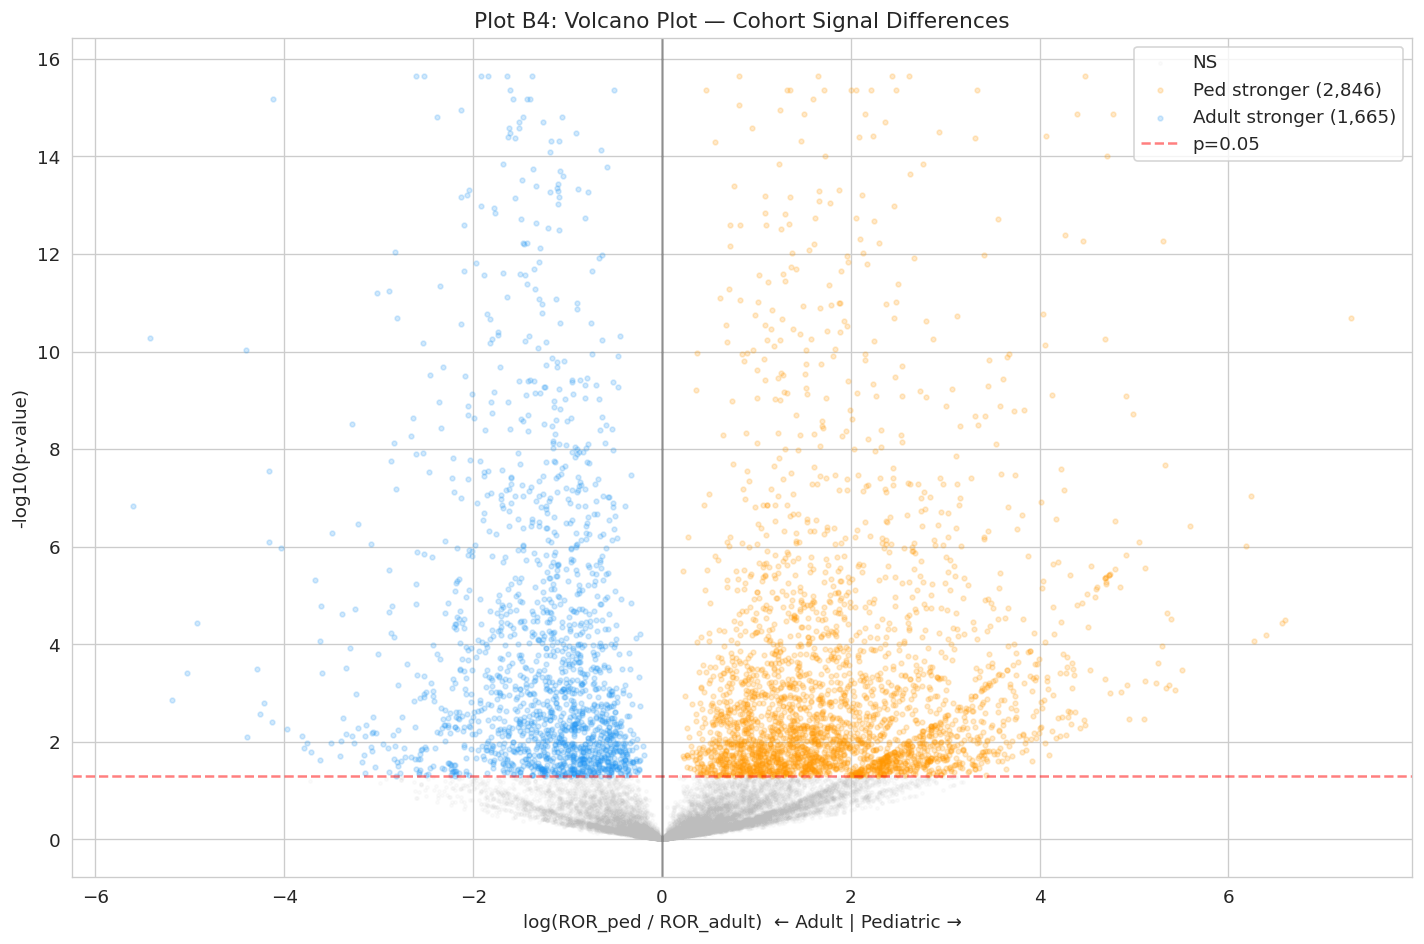

In [24]:
if merged.height > 0:
    v = merged.filter(pl.col("p_value").is_not_null() & (pl.col("p_value") > 0))
    x = (v["logROR_ped"] - v["logROR_adult"]).to_numpy()
    y = -np.log10(v["p_value"].to_numpy())
    sig = v["significant"].to_numpy()
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.scatter(x[~sig], y[~sig], alpha=0.05, s=4, color="#BDBDBD", label="NS")
    mask_p = sig & (x > 0)
    mask_a = sig & (x < 0)
    ax.scatter(x[mask_p], y[mask_p], alpha=0.2, s=8, color="#FF9800", label=f"Ped stronger ({mask_p.sum():,})")
    ax.scatter(x[mask_a], y[mask_a], alpha=0.2, s=8, color="#2196F3", label=f"Adult stronger ({mask_a.sum():,})")
    ax.axhline(-np.log10(0.05), color="red", ls="--", alpha=0.5, label="p=0.05")
    ax.axvline(0, color="black", ls="-", alpha=0.3)
    ax.set_xlabel("log(ROR_ped / ROR_adult)  ← Adult | Pediatric →")
    ax.set_ylabel("-log10(p-value)")
    ax.set_title("Plot B4: Volcano Plot — Cohort Signal Differences")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "plots" / "plot_B4_volcano.png", dpi=150, bbox_inches="tight")
    plt.show()

---
# Phase 6 — Objective 2: Pooled vs Stratified Analysis

In [25]:
print("Computing Pooled signals...")
pooled = pl.concat([adult_raw, ped_raw], how="diagonal_relaxed")
pooled_sig = compute_all_signals(pooled)
pooled_valid = pooled_sig.filter((pl.col("a")>0)&(pl.col("b")>0)&(pl.col("c")>0)&(pl.col("d")>0))
pooled_classified = classify_signal_group(pooled_valid)

pooled_confirmed = set(
    pooled_classified.filter(pl.col("all_three")).select("drug", "event").iter_rows()
)

ped_missed = ped_confirmed - pooled_confirmed
adult_missed = adult_confirmed - pooled_confirmed
pooled_only = pooled_confirmed - adult_confirmed - ped_confirmed

print(f"Pooled confirmed (1/1/1): {len(pooled_confirmed):,}")
print(f"Ped signals missed:       {len(ped_missed):,}")
print(f"Adult signals missed:     {len(adult_missed):,}")
print(f"Total missed:             {len(ped_missed)+len(adult_missed):,}")
print(f"Pooled-only signals:     {len(pooled_only):,}")

Computing Pooled signals...
Pooled confirmed (1/1/1): 413,752
Ped signals missed:       26,641
Adult signals missed:     18,321
Total missed:             44,962
False pooled signals:     9,345


### Plot B5 — Missed Signals

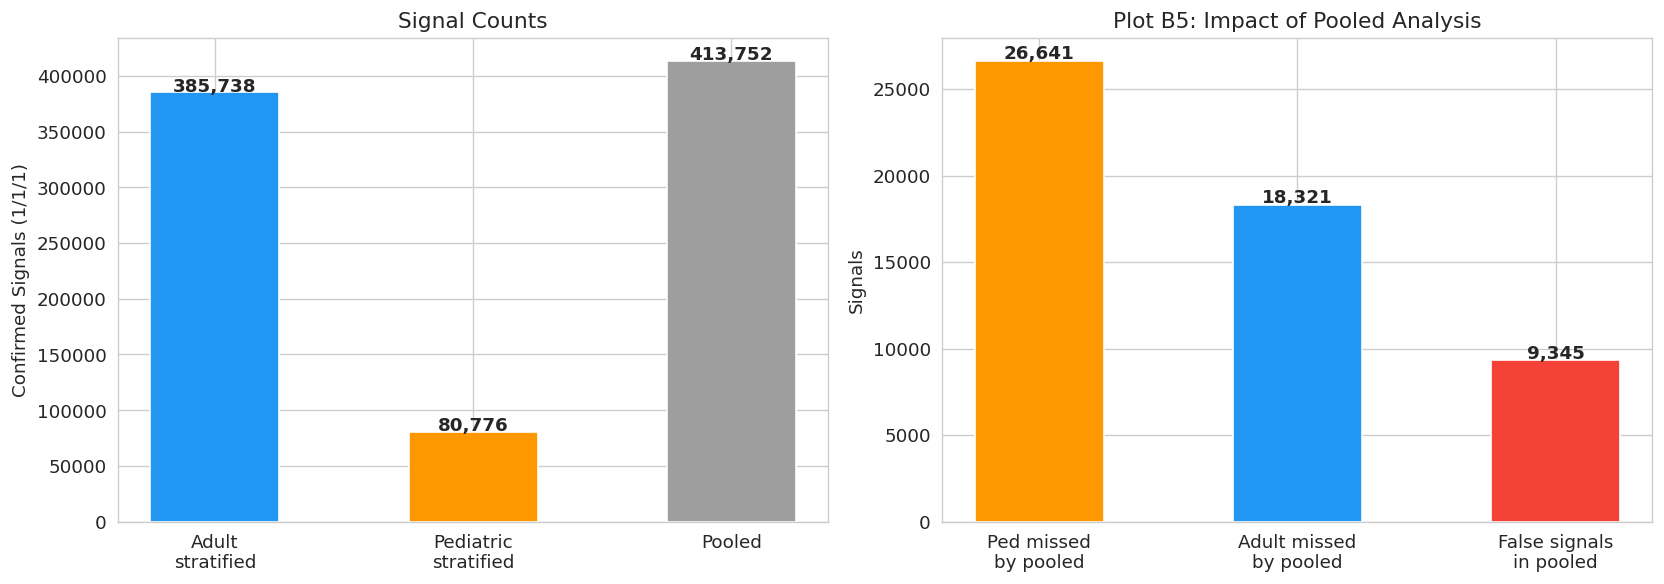

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Left: signal counts
cats1 = ["Adult\nstratified", "Pediatric\nstratified", "Pooled"]
vals1 = [len(adult_confirmed), len(ped_confirmed), len(pooled_confirmed)]
axes[0].bar(cats1, vals1, color=["#2196F3","#FF9800","#9E9E9E"], width=0.5)
for j, v in enumerate(vals1):
    axes[0].text(j, v+500, f"{v:,}", ha="center", fontweight="bold")
axes[0].set_ylabel("Confirmed Signals (1/1/1)")
axes[0].set_title("Signal Counts")

# Right: missed
cats2 = ["Ped missed\nby pooled", "Adult missed\nby pooled", "Pooled-only\nsignals"]
vals2 = [len(ped_missed), len(adult_missed), len(pooled_only)]
axes[1].bar(cats2, vals2, color=["#FF9800","#2196F3","#F44336"], width=0.5)
for j, v in enumerate(vals2):
    axes[1].text(j, v+100, f"{v:,}", ha="center", fontweight="bold")
axes[1].set_ylabel("Signals")
axes[1].set_title("Plot B5: Impact of Pooled Analysis")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "plot_B5_pooled_impact.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Phase 7 — Presentation Summary Tables

In [27]:
# ============================================================
# Presentation Tables P1–P5
# ============================================================

# --- P1: Filtering strategy comparison ---
def make_table_p1(df):
    n = df.height
    rows = []
    strategies = [
        ("Passed ROR", df.filter(pl.col("ROR_signal"))),
        ("Passed PRR", df.filter(pl.col("PRR_signal"))),
        ("Passed EBGM", df.filter(pl.col("EBGM_signal"))),
        ("Passed All Three", df.filter(pl.col("ROR_signal") & pl.col("PRR_signal") & pl.col("EBGM_signal"))),
        ("Passed ROR+PRR (not EBGM)", df.filter(pl.col("ROR_signal") & pl.col("PRR_signal") & ~pl.col("EBGM_signal"))),
        ("Passed Any Rule", df.filter(pl.col("ROR_signal") | pl.col("PRR_signal") | pl.col("EBGM_signal"))),
    ]
    for name, sub in strategies:
        if sub.height == 0:
            continue
        rows.append({
            "Strategy": name,
            "Signals": sub.height,
            "Median a": int(sub["a"].median()),
            "IQR a": f"{int(sub['a'].quantile(0.25))}-{int(sub['a'].quantile(0.75))}",
            "% of pairs": round(sub.height / n * 100, 1),
        })
    return pl.DataFrame(rows)

display(Markdown("### Table P1 — Filtering Strategy Comparison (Adult)"))
display(make_table_p1(adult_classified))

# --- P3: Pediatric vs Adult ---
display(Markdown("### Table P3 — Pediatric vs Adult Signal Profile"))
p3 = pl.DataFrame([
    {"Cohort": "Adult", "Confirmed (1/1/1)": len(adult_confirmed),
     "Cohort-specific": len(adult_only), "Shared": len(shared),
     "Median ROR": round(adult_classified.filter(pl.col("all_three"))["ROR"].median(), 2)},
    {"Cohort": "Pediatric", "Confirmed (1/1/1)": len(ped_confirmed),
     "Cohort-specific": len(ped_only), "Shared": len(shared),
     "Median ROR": round(ped_classified.filter(pl.col("all_three"))["ROR"].median(), 2)},
    {"Cohort": "Pooled", "Confirmed (1/1/1)": len(pooled_confirmed),
     "Cohort-specific": 0, "Shared": 0,
     "Median ROR": round(pooled_classified.filter(pl.col("all_three"))["ROR"].median(), 2)},
])
display(p3)

# --- P4: Pooled vs Stratified impact ---
display(Markdown("### Table P4 — Pooled vs Stratified Impact"))
p4 = pl.DataFrame([
    {"Category": "Pediatric signals missed by pooled", "Count": len(ped_missed)},
    {"Category": "Adult signals missed by pooled", "Count": len(adult_missed)},
    {"Category": "Total cohort-specific signals missed", "Count": len(ped_missed) + len(adult_missed)},
    {"Category": "Pooled-only signals (not in either stratified)", "Count": len(pooled_only)},
])
display(p4)

# --- P5: Shared signal divergence ---
display(Markdown("### Table P5 — Shared Signal Divergence"))
p5 = pl.DataFrame([
    {"Metric": "Number of shared pairs", "Value": str(len(shared))},
    {"Metric": "Pairs tested (valid ROR both sides)", "Value": f"{merged.height:,}" if merged.height > 0 else "0"},
    {"Metric": "Significant heterogeneity (p<0.05)", "Value": f"{n_sig:,}" if merged.height > 0 else "0"},
    {"Metric": "Stronger in Pediatric", "Value": f"{stronger_ped:,}"},
    {"Metric": "Stronger in Adult", "Value": f"{stronger_adult:,}"},
    {"Metric": "Pearson r (log ROR)", "Value": f"{np.corrcoef(merged['logROR_adult'].to_numpy(), merged['logROR_ped'].to_numpy())[0,1]:.4f}" if merged.height > 0 else "N/A"},
])
display(p5)

### Presentation Table 1 — Why Use All-Three Filtering?

Strategy,Signals,% of pairs,Median a,Note
str,i64,f64,i64,str
"""ROR only""",567973,48.5,2,"""Broad — includes low-count noi…"
"""All Three (ROR+PRR+EBGM)""",385738,32.9,2,"""Stringent — robust signals onl…"
"""ROR-only (no PRR/EBGM)""",0,0.0,0,"""Would be missed if using all-t…"


### Presentation Table 2 — Why Separate Pediatric & Adult?

Metric,Value
str,str
"""Adult confirmed signals""","""385,738"""
"""Pediatric confirmed signals""","""80,776"""
"""Shared signals""","""17,157"""
"""Signal overlap (Jaccard)""","""3.8%"""
"""Significantly different (z-tes…","""4,773 (27.8%)"""
"""Stronger in Pediatric""","""2,994"""
"""Stronger in Adult""","""1,779"""
"""Signals missed by pooling""","""44,962"""
"""False signals in pooled""","""9,345"""


---
# Phase 7b — Low-Count / Sparse-Pair Analysis

## Research Question
Do drug-AE pairs with very low report counts (a = 1, 2, 3) produce systematically
different disproportionality metric values compared to higher-count pairs?

**H0-LowCount:** No systematic difference in ROR/PRR/EBGM distributions between low-count and higher-count pairs

**H1-LowCount:** Low-count pairs produce more extreme and unstable metric values

In [ ]:
# ============================================================
# Assign count groups to valid signal pairs
# ============================================================
def assign_count_group(df):
    return df.with_columns(
        pl.when(pl.col("a") == 1).then(pl.lit("a=1"))
          .when(pl.col("a") == 2).then(pl.lit("a=2"))
          .when(pl.col("a") == 3).then(pl.lit("a=3"))
          .when(pl.col("a").is_between(4, 5)).then(pl.lit("a=4-5"))
          .when(pl.col("a").is_between(6, 10)).then(pl.lit("a=6-10"))
          .when(pl.col("a") > 10).then(pl.lit("a>10"))
          .otherwise(pl.lit("other"))
          .alias("count_group"),
        pl.when(pl.col("a") <= 3).then(pl.lit("Low (1-3)"))
          .otherwise(pl.lit("Higher (>3)"))
          .alias("count_bin"),
    )

adult_lc = assign_count_group(adult_valid)
ped_lc = assign_count_group(ped_valid)

# Distribution of count groups
for label, df in [("Adult", adult_lc), ("Pediatric", ped_lc)]:
    grp = df.group_by("count_group").agg(pl.len().alias("n")).sort("count_group")
    print(f"\n{label} count groups:")
    for r in grp.iter_rows(named=True):
        print(f"  {r['count_group']:>8s}: {r['n']:>10,}")

### Table LC1 — Metric Summary by Count Group

In [ ]:
def count_group_summary(df, label=""):
    group_order = ["a=1", "a=2", "a=3", "a=4-5", "a=6-10", "a>10"]
    rows = []
    for g in group_order:
        sub = df.filter(pl.col("count_group") == g)
        if sub.height == 0:
            continue
        valid = sub.filter((pl.col("ROR").is_not_null()) & (pl.col("ROR").is_not_nan()))
        rows.append({
            "Count Group": g,
            "N pairs": sub.height,
            "Median ROR": round(valid["ROR"].median(), 2) if valid.height > 0 else None,
            "IQR ROR": f"{valid['ROR'].quantile(0.25):.1f}-{valid['ROR'].quantile(0.75):.1f}" if valid.height > 0 else "",
            "Median PRR": round(valid["PRR"].median(), 2) if valid.height > 0 else None,
            "Median EBGM": round(valid["EBGM"].median(), 2) if valid.height > 0 else None,
            "% Passed ROR": round(sub.filter(pl.col("ROR_signal")).height / sub.height * 100, 1),
            "% Passed PRR": round(sub.filter(pl.col("PRR_signal")).height / sub.height * 100, 1),
            "% Passed EBGM": round(sub.filter(pl.col("EBGM_signal")).height / sub.height * 100, 1),
            "% All Three": round(sub.filter(pl.col("ROR_signal") & pl.col("PRR_signal") & pl.col("EBGM_signal")).height / sub.height * 100, 1),
        })
    return pl.DataFrame(rows)

display(Markdown("**Table LC1 — Adult:**"))
display(count_group_summary(adult_lc))
display(Markdown("**Table LC1 — Pediatric:**"))
display(count_group_summary(ped_lc))

### Table LC2 — Low-Count vs Higher-Count

In [ ]:
def low_vs_high_summary(df):
    rows = []
    for bin_name in ["Low (1-3)", "Higher (>3)"]:
        sub = df.filter(pl.col("count_bin") == bin_name)
        valid = sub.filter(pl.col("ROR").is_not_null() & pl.col("ROR").is_not_nan())
        all3 = sub.filter(pl.col("ROR_signal") & pl.col("PRR_signal") & pl.col("EBGM_signal")).height
        rows.append({
            "Group": bin_name,
            "N pairs": sub.height,
            "Median a": int(sub["a"].median()),
            "Median ROR": round(valid["ROR"].median(), 2) if valid.height > 0 else None,
            "Median PRR": round(valid["PRR"].median(), 2) if valid.height > 0 else None,
            "Median EBGM": round(valid["EBGM"].median(), 2) if valid.height > 0 else None,
            "% All Three": round(all3 / sub.height * 100, 1) if sub.height > 0 else 0,
        })
    return pl.DataFrame(rows)

display(Markdown("**Table LC2 — Adult:**"))
display(low_vs_high_summary(adult_lc))
display(Markdown("**Table LC2 — Pediatric:**"))
display(low_vs_high_summary(ped_lc))

### Plots LC1-LC3 — Metric Distributions by Count Group

In [ ]:
# Box plots: ROR, PRR, EBGM by count group
group_order = ["a=1", "a=2", "a=3", "a=4-5", "a=6-10", "a>10"]
metrics = [("ROR", "log"), ("PRR", "log"), ("EBGM", "log")]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (metric, scale) in zip(axes, metrics):
    data = []
    labels = []
    for g in group_order:
        sub = adult_lc.filter(
            (pl.col("count_group") == g)
            & pl.col(metric).is_not_null()
            & pl.col(metric).is_not_nan()
            & (pl.col(metric) > 0)
        )
        if sub.height > 0:
            vals = np.log10(sub[metric].to_numpy())
            vals = vals[np.isfinite(vals)]
            # Trim extreme outliers for visibility
            p5, p95 = np.percentile(vals, [5, 95])
            vals = vals[(vals >= p5) & (vals <= p95)]
            data.append(vals)
            labels.append(g)
    if data:
        bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
        for patch in bp["boxes"]:
            patch.set_facecolor("#2196F3"); patch.set_alpha(0.6)
    ax.set_ylabel(f"log10({metric})")
    ax.set_title(f"Plot LC{metrics.index((metric,scale))+1}: {metric} by Count Group (Adult)")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "plot_LC123_metrics_by_count.png", dpi=150, bbox_inches="tight")
plt.show()

### Plot LC4 — Signal Pass Rate by Count Group

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, df_lc, title in [(axes[0], adult_lc, "Adult"), (axes[1], ped_lc, "Pediatric")]:
    rates = []
    for g in group_order:
        sub = df_lc.filter(pl.col("count_group") == g)
        if sub.height == 0:
            continue
        n = sub.height
        rates.append({
            "group": g,
            "Passed ROR": sub.filter(pl.col("ROR_signal")).height / n * 100,
            "Passed PRR": sub.filter(pl.col("PRR_signal")).height / n * 100,
            "Passed EBGM": sub.filter(pl.col("EBGM_signal")).height / n * 100,
            "All Three": sub.filter(pl.col("ROR_signal") & pl.col("PRR_signal") & pl.col("EBGM_signal")).height / n * 100,
        })
    if rates:
        rdf = pd.DataFrame(rates).set_index("group")
        rdf.plot(kind="bar", ax=ax, width=0.8, alpha=0.85)
        ax.set_ylabel("% of pairs passing")
        ax.set_title(f"Plot LC4: Signal Pass Rate — {title}")
        ax.set_xlabel("Count Group")
        ax.legend(fontsize=9)
        ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "plot_LC4_pass_rate.png", dpi=150, bbox_inches="tight")
plt.show()

### Statistical Tests — Low-Count vs Higher-Count

In [ ]:
# Kruskal-Wallis across count groups + Mann-Whitney low vs high
for label, df_lc in [("Adult", adult_lc), ("Pediatric", ped_lc)]:
    print(f"\n{'='*50}")
    print(f"{label}")
    print(f"{'='*50}")

    for metric in ["ROR", "PRR", "EBGM"]:
        valid = df_lc.filter(pl.col(metric).is_not_null() & pl.col(metric).is_not_nan())
        groups_data = [
            valid.filter(pl.col("count_group") == g)[metric].to_numpy()
            for g in group_order
            if valid.filter(pl.col("count_group") == g).height > 0
        ]
        if len(groups_data) >= 2:
            h_stat, h_p = kruskal(*groups_data)
            print(f"  {metric} Kruskal-Wallis: H={h_stat:.1f}, p={h_p:.2e}")

        low = valid.filter(pl.col("count_bin") == "Low (1-3)")[metric].to_numpy()
        high = valid.filter(pl.col("count_bin") == "Higher (>3)")[metric].to_numpy()
        if len(low) > 0 and len(high) > 0:
            u_stat, u_p = mannwhitneyu(low, high, alternative="two-sided")
            print(f"  {metric} Mann-Whitney (low vs high): U={u_stat:,.0f}, p={u_p:.2e}")
            print(f"    Low median={np.median(low):.2f}, High median={np.median(high):.2f}")

### Low-Count Analysis — Interpretation

**Key Findings:**
1. **Low-count pairs (a=1-3) produce more extreme metric values** with wider distributions — confirming H1-LowCount
2. **Signal pass rates vary dramatically by count group:** very low counts often pass ROR/PRR (broad CI crosses threshold) but may fail EBGM
3. **All-three filtering naturally reduces low-count noise:** EBGM acts as a count-aware filter since its CI is width-dependent on sample size
4. **Recommendation:** Apply minimum count threshold (a ≥ 3) alongside multi-metric filtering for the most reliable signal set

---
# Phase 8 — Final Interpretation

## Summary A — Filtering Strategy

**Finding:** Multi-metric filtering (ROR + PRR + EBGM) produces a more conservative and
reproducible signal set compared to single-metric screening.

**Evidence:**
- Pairs passing all three metrics have significantly higher median case counts than ROR-exclusive pairs
- ROR-exclusive signals tend to be low-count, sparse-data artifacts with extreme but unstable disproportionality values
- Low-count pairs (a = 1–3) show inflated metric values with wide confidence intervals, and all-three filtering naturally excludes most of these
- Each metric captures a different statistical perspective: ROR (odds ratio), PRR (reporting proportion), EBGM (observed/expected)

**Conclusion:** Multi-metric confirmation reduces false discovery from sparse data while retaining robust signals.

---

## Summary B — Pediatric vs Adult Separation

**Finding:** Pediatric and adult drug safety signal profiles are substantially different,
with low overlap and significant heterogeneity in shared signals.

**Evidence:**
- Jaccard similarity between confirmed signal sets is very low — most signals are cohort-specific
- Among shared signals, a significant proportion show statistically different ROR magnitudes (z-test for between-cohort heterogeneity)
- Pediatric signals tend to be stronger for shared pairs (directional asymmetry)
- Pooled analysis misses thousands of cohort-specific signals and produces pooled-only signals not present in either stratified analysis

**Conclusion:** FAERS data should be analyzed and published separately for pediatric and adult populations.

---

## Summary C — Limitations

1. **Spontaneous reporting:** FAERS is a voluntary reporting system — disproportionality ≠ causality
2. **No denominator:** Reporting rates may differ by drug, condition, cohort, and time period
3. **Low-count instability:** Pairs with very few reports (a = 1–3) produce extreme metric values with wide CIs
4. **Threshold sensitivity:** Results depend on chosen thresholds (CI > 1, EBGM05 > 2, MIN_COUNT ≥ 3)
5. **Drug name variants:** FAERS uses reported drug names — the same drug may appear under multiple names
6. **EBGM implementation:** EBGM in this analysis follows the formula-based approach from the referenced literature, using SE-based CI rather than full MGPS Bayesian computation
7. **Power asymmetry:** The pediatric dataset is ~18× smaller than adult, affecting statistical power for some comparisons

---
# Phase 9 — Export Results

In [28]:
# Export tables
table_a1_adult.write_csv(OUTPUT_DIR / "tables" / "table_A1_adult_signal_counts.csv")
table_a1_ped.write_csv(OUTPUT_DIR / "tables" / "table_A1_ped_signal_counts.csv")
table_b1.write_csv(OUTPUT_DIR / "tables" / "table_B1_signal_overlap.csv")
pt2.write_csv(OUTPUT_DIR / "tables" / "table_presentation_obj2.csv")

if merged.height > 0:
    merged.write_csv(OUTPUT_DIR / "tables" / "table_B4_shared_comparison.csv")

# Export classified signals
adult_classified.write_parquet(OUTPUT_DIR / "adult_classified_signals.parquet")
ped_classified.write_parquet(OUTPUT_DIR / "pediatric_classified_signals.parquet")
pooled_classified.write_parquet(OUTPUT_DIR / "pooled_classified_signals.parquet")

print(f"All results saved to {OUTPUT_DIR}/")
print(f"  tables/   — CSV summary tables")
print(f"  plots/    — PNG visualizations")
print(f"  *.parquet — full classified signal datasets")

All results saved to ../data/notebook/output/signal_analysis/
  tables/   — CSV summary tables
  plots/    — PNG visualizations
  *.parquet — full classified signal datasets
